# 08 - Model Comparison and Best Model Selection

## Student Health Risk Prediction

This notebook compares the best-performing variants from four classification model families:

1. Logistic Regression
2. Random Forest
3. Support Vector Machine
4. MLP Neural Network

The primary model-selection metric is **Balanced Accuracy**, which is appropriate for the strongly imbalanced multiclass target distribution.

Secondary evaluation metrics include:

- Accuracy
- Macro Precision
- Macro Recall
- Macro F1-score

The final model is selected automatically according to validation Balanced Accuracy.

In [1]:
from pathlib import Path

import sys
import platform
import json
import shutil
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sklearn

RANDOM_STATE = 42

print("Python Version:", sys.version.split()[0])
print("Platform:", platform.platform())
print("NumPy Version:", np.__version__)
print("Pandas Version:", pd.__version__)
print("Scikit-learn Version:", sklearn.__version__)
print("Random State:", RANDOM_STATE)

Python Version: 3.14.0
Platform: macOS-26.5.1-arm64-arm-64bit-Mach-O
NumPy Version: 2.4.6
Pandas Version: 3.0.3
Scikit-learn Version: 1.8.0
Random State: 42


In [2]:
PROJECT_ROOT = Path.cwd().resolve()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

MODELS_DIR = PROJECT_ROOT / "models"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
FIGURES_DIR = OUTPUTS_DIR / "figures"

MODELS_DIR.mkdir(parents=True, exist_ok=True)
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Project Root:", PROJECT_ROOT)
print("Models Directory:", MODELS_DIR)
print("Outputs Directory:", OUTPUTS_DIR)
print("Figures Directory:", FIGURES_DIR)

Project Root: /Users/admin/Documents/ICBT/Computational Intelligence/Student Health Risk Prediction
Models Directory: /Users/admin/Documents/ICBT/Computational Intelligence/Student Health Risk Prediction/models
Outputs Directory: /Users/admin/Documents/ICBT/Computational Intelligence/Student Health Risk Prediction/outputs
Figures Directory: /Users/admin/Documents/ICBT/Computational Intelligence/Student Health Risk Prediction/outputs/figures


In [3]:
result_files = {
    "Logistic Regression": OUTPUTS_DIR / "logistic_regression_model_comparison.csv",
    "Random Forest": OUTPUTS_DIR / "random_forest_model_comparison.csv",
    "SVM": OUTPUTS_DIR / "svm_model_comparison.csv",
    "MLP Neural Network": OUTPUTS_DIR / "mlp_model_comparison.csv",
}

availability = []

for family, path in result_files.items():
    availability.append({
        "Model Family": family,
        "File": path.name,
        "Exists": path.exists()
    })

availability_df = pd.DataFrame(availability)
availability_df

,Model Family,File,Exists
0,Logistic Regression,logistic_regression_model_comparison.csv,False
1,Random Forest,random_forest_model_comparison.csv,False
2,SVM,svm_model_comparison.csv,True
3,MLP Neural Network,mlp_model_comparison.csv,True


In [6]:
all_results = []

for family, path in result_files.items():
    if not path.exists():
        raise FileNotFoundError(
            f"Missing comparison file for {family}: {path}"
        )

    df = pd.read_csv(path)
    df["Model Family"] = family
    all_results.append(df)

all_model_results = pd.concat(
    all_results,
    ignore_index=True
)

print("Combined Results Shape:", all_model_results.shape)
all_model_results

Combined Results Shape: (12, 7)


,Model,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1,Model Family
0,Baseline Logistic Regression,0.952600,0.842800,0.904000,0.842800,0.871200,Logistic Regression
1,Class-Weighted Logistic Regression,0.833400,0.898900,0.632500,0.898900,0.706400,Logistic Regression
2,Tuned Logistic Regression,0.833400,0.898900,0.632500,0.898900,0.706400,Logistic Regression
3,Baseline Random Forest,0.966171,0.865409,0.956840,0.865409,0.906597,Random Forest
4,Class-Weighted Random Forest,0.965280,0.865024,0.951907,0.865024,0.904279,Random Forest
5,Tuned Random Forest,0.948108,0.945314,0.829592,0.945314,0.879829,Random Forest
6,Baseline Linear SVM,0.922075,0.640977,0.940012,0.640977,0.730748,SVM
7,Class-Weighted Linear SVM,0.892811,0.881395,0.709208,0.881395,0.773118,SVM
8,Tuned Linear SVM,0.892811,0.881395,0.709208,0.881395,0.773118,SVM
9,Baseline MLP Neural Network,0.965512,0.863694,0.954728,0.863694,0.904679,MLP Neural Network


In [7]:
print("Columns:")
print(all_model_results.columns.tolist())

all_model_results.head()

Columns:
['Model', 'Accuracy', 'Balanced Accuracy', 'Macro Precision', 'Macro Recall', 'Macro F1', 'Model Family']


,Model,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1,Model Family
0,Baseline Logistic Regression,0.952600,0.842800,0.904000,0.842800,0.871200,Logistic Regression
1,Class-Weighted Logistic Regression,0.833400,0.898900,0.632500,0.898900,0.706400,Logistic Regression
2,Tuned Logistic Regression,0.833400,0.898900,0.632500,0.898900,0.706400,Logistic Regression
3,Baseline Random Forest,0.966171,0.865409,0.956840,0.865409,0.906597,Random Forest
4,Class-Weighted Random Forest,0.965280,0.865024,0.951907,0.865024,0.904279,Random Forest


In [8]:
metric_columns = [
    "Accuracy",
    "Balanced Accuracy",
    "Macro Precision",
    "Macro Recall",
    "Macro F1"
]

for column in metric_columns:
    all_model_results[column] = pd.to_numeric(
        all_model_results[column],
        errors="coerce"
    )

print("Missing metric values:")
print(all_model_results[metric_columns].isna().sum())

all_model_results

Missing metric values:
Accuracy             0
Balanced Accuracy    0
Macro Precision      0
Macro Recall         0
Macro F1             0
dtype: int64


,Model,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1,Model Family
0,Baseline Logistic Regression,0.952600,0.842800,0.904000,0.842800,0.871200,Logistic Regression
1,Class-Weighted Logistic Regression,0.833400,0.898900,0.632500,0.898900,0.706400,Logistic Regression
2,Tuned Logistic Regression,0.833400,0.898900,0.632500,0.898900,0.706400,Logistic Regression
3,Baseline Random Forest,0.966171,0.865409,0.956840,0.865409,0.906597,Random Forest
4,Class-Weighted Random Forest,0.965280,0.865024,0.951907,0.865024,0.904279,Random Forest
5,Tuned Random Forest,0.948108,0.945314,0.829592,0.945314,0.879829,Random Forest
6,Baseline Linear SVM,0.922075,0.640977,0.940012,0.640977,0.730748,SVM
7,Class-Weighted Linear SVM,0.892811,0.881395,0.709208,0.881395,0.773118,SVM
8,Tuned Linear SVM,0.892811,0.881395,0.709208,0.881395,0.773118,SVM
9,Baseline MLP Neural Network,0.965512,0.863694,0.954728,0.863694,0.904679,MLP Neural Network


In [9]:
full_ranking = (
    all_model_results
    .sort_values(
        by=["Balanced Accuracy", "Macro F1"],
        ascending=[False, False]
    )
    .reset_index(drop=True)
)

full_ranking.index = full_ranking.index + 1
full_ranking.index.name = "Rank"

full_ranking[
    [
        "Model",
        "Model Family",
        "Accuracy",
        "Balanced Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1"
    ]
].round(4)

,Model,Model Family,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1
Rank,,,,,,,
1,Tuned Random Forest,Random Forest,0.9481,0.9453,0.8296,0.9453,0.8798
2,Tuned MLP Neural Network,MLP Neural Network,0.9347,0.9453,0.7955,0.9453,0.8568
3,Balanced-Training MLP Neural Network,MLP Neural Network,0.9339,0.9449,0.7957,0.9449,0.8566
4,Class-Weighted Logistic Regression,Logistic Regression,0.8334,0.8989,0.6325,0.8989,0.7064
5,Tuned Logistic Regression,Logistic Regression,0.8334,0.8989,0.6325,0.8989,0.7064
6,Class-Weighted Linear SVM,SVM,0.8928,0.8814,0.7092,0.8814,0.7731
7,Tuned Linear SVM,SVM,0.8928,0.8814,0.7092,0.8814,0.7731
8,Baseline Random Forest,Random Forest,0.9662,0.8654,0.9568,0.8654,0.9066
9,Class-Weighted Random Forest,Random Forest,0.9653,0.8650,0.9519,0.8650,0.9043


In [10]:
best_per_family = (
    all_model_results
    .sort_values(
        by=["Balanced Accuracy", "Macro F1"],
        ascending=[False, False]
    )
    .groupby(
        "Model Family",
        as_index=False
    )
    .first()
)

best_per_family = (
    best_per_family
    .sort_values(
        by=["Balanced Accuracy", "Macro F1"],
        ascending=[False, False]
    )
    .reset_index(drop=True)
)

best_per_family

,Model Family,Model,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1
0,Random Forest,Tuned Random Forest,0.948108,0.945314,0.829592,0.945314,0.879829
1,MLP Neural Network,Tuned MLP Neural Network,0.934668,0.945256,0.795501,0.945256,0.856781
2,Logistic Regression,Class-Weighted Logistic Regression,0.833400,0.898900,0.632500,0.898900,0.706400
3,SVM,Class-Weighted Linear SVM,0.892811,0.881395,0.709208,0.881395,0.773118


In [11]:
best_family_table = best_per_family[
    [
        "Model Family",
        "Model",
        "Accuracy",
        "Balanced Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1"
    ]
].copy()

best_family_table[
    [
        "Accuracy",
        "Balanced Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1"
    ]
] = best_family_table[
    [
        "Accuracy",
        "Balanced Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1"
    ]
].round(4)

best_family_table

,Model Family,Model,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1
0,Random Forest,Tuned Random Forest,0.9481,0.9453,0.8296,0.9453,0.8798
1,MLP Neural Network,Tuned MLP Neural Network,0.9347,0.9453,0.7955,0.9453,0.8568
2,Logistic Regression,Class-Weighted Logistic Regression,0.8334,0.8989,0.6325,0.8989,0.7064
3,SVM,Class-Weighted Linear SVM,0.8928,0.8814,0.7092,0.8814,0.7731


In [12]:
best_model_row = (
    all_model_results
    .sort_values(
        by=["Balanced Accuracy", "Macro F1"],
        ascending=[False, False]
    )
    .iloc[0]
)

print("=" * 70)
print("FINAL MODEL SELECTION")
print("=" * 70)
print("Selection Metric: Balanced Accuracy")
print("Best Model Family:", best_model_row["Model Family"])
print("Best Model Variant:", best_model_row["Model"])
print(
    "Balanced Accuracy:",
    round(best_model_row["Balanced Accuracy"], 6)
)
print(
    "Accuracy:",
    round(best_model_row["Accuracy"], 6)
)
print(
    "Macro Precision:",
    round(best_model_row["Macro Precision"], 6)
)
print(
    "Macro Recall:",
    round(best_model_row["Macro Recall"], 6)
)
print(
    "Macro F1:",
    round(best_model_row["Macro F1"], 6)
)

FINAL MODEL SELECTION
Selection Metric: Balanced Accuracy
Best Model Family: Random Forest
Best Model Variant: Tuned Random Forest
Balanced Accuracy: 0.945314
Accuracy: 0.948108
Macro Precision: 0.829592
Macro Recall: 0.945314
Macro F1: 0.879829


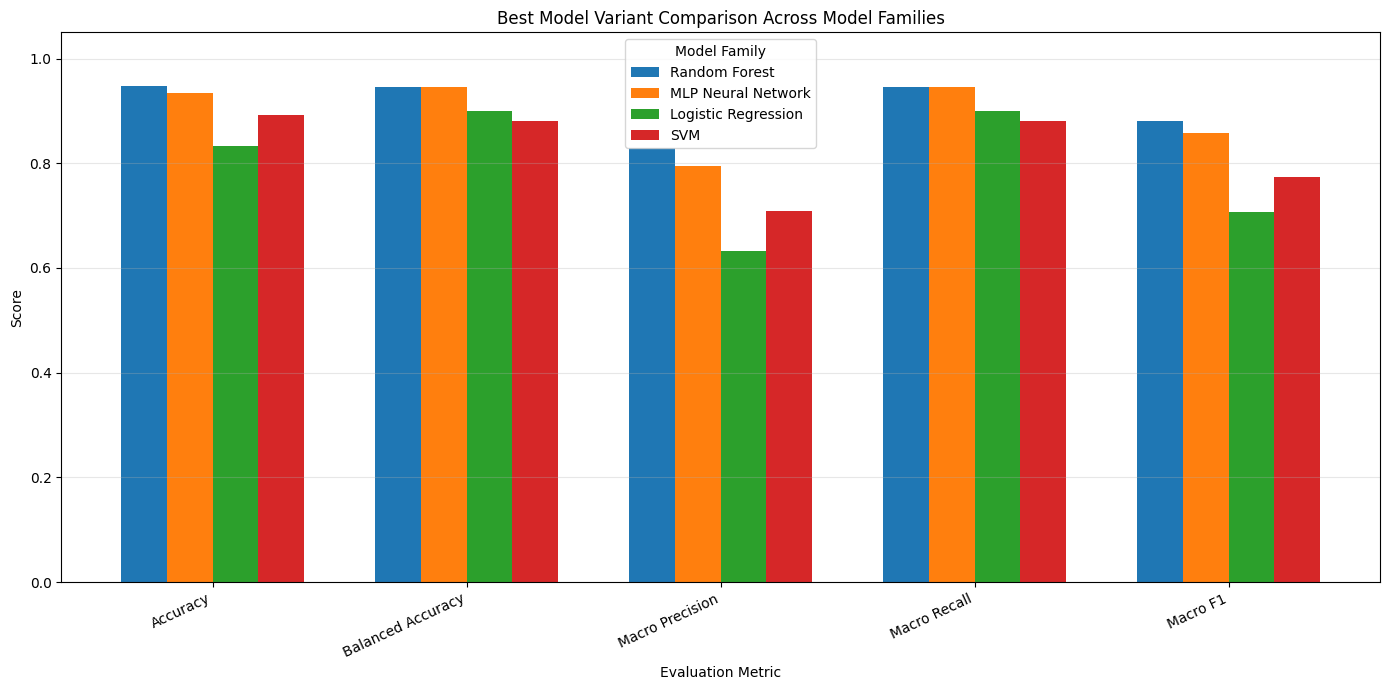

Saved Figure: /Users/admin/Documents/ICBT/Computational Intelligence/Student Health Risk Prediction/outputs/figures/best_model_family_comparison.png


In [13]:
plot_df = best_per_family.copy()

metrics_to_plot = [
    "Accuracy",
    "Balanced Accuracy",
    "Macro Precision",
    "Macro Recall",
    "Macro F1"
]

x = np.arange(len(metrics_to_plot))
width = 0.18

fig, ax = plt.subplots(figsize=(14, 7))

for i, (_, row) in enumerate(plot_df.iterrows()):
    values = [
        row[metric]
        for metric in metrics_to_plot
    ]

    ax.bar(
        x + i * width,
        values,
        width,
        label=row["Model Family"]
    )

ax.set_title(
    "Best Model Variant Comparison Across Model Families"
)
ax.set_xlabel("Evaluation Metric")
ax.set_ylabel("Score")
ax.set_xticks(
    x + width * (len(plot_df) - 1) / 2
)
ax.set_xticklabels(
    metrics_to_plot,
    rotation=25,
    ha="right"
)
ax.set_ylim(0, 1.05)
ax.legend(title="Model Family")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()

comparison_figure_path = (
    FIGURES_DIR /
    "best_model_family_comparison.png"
)

plt.savefig(
    comparison_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved Figure:", comparison_figure_path)

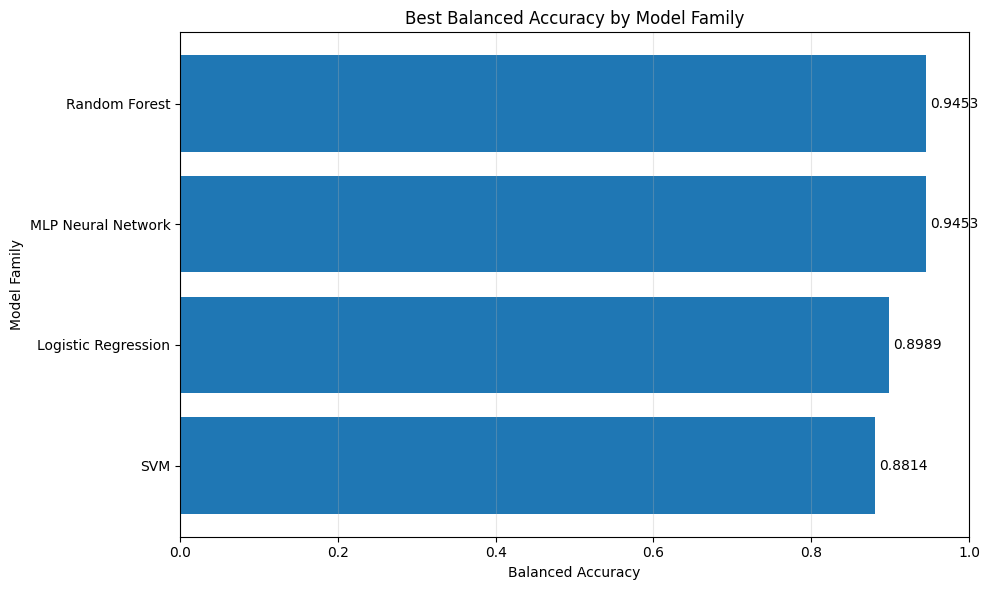

Saved Figure: /Users/admin/Documents/ICBT/Computational Intelligence/Student Health Risk Prediction/outputs/figures/balanced_accuracy_model_ranking.png


In [14]:
ranking_plot_df = (
    best_per_family
    .sort_values(
        "Balanced Accuracy",
        ascending=True
    )
)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    ranking_plot_df["Model Family"],
    ranking_plot_df["Balanced Accuracy"]
)

ax.set_title(
    "Best Balanced Accuracy by Model Family"
)
ax.set_xlabel("Balanced Accuracy")
ax.set_ylabel("Model Family")
ax.set_xlim(0, 1.0)
ax.grid(axis="x", alpha=0.3)

for bar, value in zip(
    bars,
    ranking_plot_df["Balanced Accuracy"]
):
    ax.text(
        value + 0.005,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.4f}",
        va="center"
    )

plt.tight_layout()

balanced_accuracy_figure_path = (
    FIGURES_DIR /
    "balanced_accuracy_model_ranking.png"
)

plt.savefig(
    balanced_accuracy_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved Figure:",
    balanced_accuracy_figure_path
)

In [15]:
top_two = (
    best_per_family
    .sort_values(
        "Balanced Accuracy",
        ascending=False
    )
    .head(2)
    .reset_index(drop=True)
)

top_two

,Model Family,Model,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1
0,Random Forest,Tuned Random Forest,0.948108,0.945314,0.829592,0.945314,0.879829
1,MLP Neural Network,Tuned MLP Neural Network,0.934668,0.945256,0.795501,0.945256,0.856781


In [16]:
if len(top_two) >= 2:
    difference = (
        top_two.loc[0, "Balanced Accuracy"]
        - top_two.loc[1, "Balanced Accuracy"]
    )

    print("Top Model:", top_two.loc[0, "Model"])
    print(
        "Top Balanced Accuracy:",
        round(
            top_two.loc[0, "Balanced Accuracy"],
            6
        )
    )

    print()

    print(
        "Second Model:",
        top_two.loc[1, "Model"]
    )
    print(
        "Second Balanced Accuracy:",
        round(
            top_two.loc[1, "Balanced Accuracy"],
            6
        )
    )

    print()

    print(
        "Absolute Difference:",
        round(difference, 6)
    )

Top Model: Tuned Random Forest
Top Balanced Accuracy: 0.945314

Second Model: Tuned MLP Neural Network
Second Balanced Accuracy: 0.945256

Absolute Difference: 5.8e-05


In [17]:
full_results_path = (
    OUTPUTS_DIR /
    "all_model_comparison.csv"
)

best_family_path = (
    OUTPUTS_DIR /
    "best_model_per_family.csv"
)

full_ranking.to_csv(
    full_results_path,
    index=True
)

best_family_table.to_csv(
    best_family_path,
    index=False
)

print("Saved Full Comparison:")
print(full_results_path)

print("\nSaved Best Model per Family:")
print(best_family_path)

Saved Full Comparison:
/Users/admin/Documents/ICBT/Computational Intelligence/Student Health Risk Prediction/outputs/all_model_comparison.csv

Saved Best Model per Family:
/Users/admin/Documents/ICBT/Computational Intelligence/Student Health Risk Prediction/outputs/best_model_per_family.csv


In [18]:
model_artifact_map = {
    "Baseline Logistic Regression":
        MODELS_DIR / "baseline_logistic_regression.pkl",

    "Class-Weighted Logistic Regression":
        MODELS_DIR / "class_weighted_logistic_regression.pkl",

    "Tuned Logistic Regression":
        MODELS_DIR / "best_logistic_regression.pkl",

    "Baseline Random Forest":
        MODELS_DIR / "baseline_random_forest.pkl",

    "Class-Weighted Random Forest":
        MODELS_DIR / "class_weighted_random_forest.pkl",

    "Tuned Random Forest":
        MODELS_DIR / "best_random_forest.pkl",

    "Baseline Linear SVM":
        MODELS_DIR / "baseline_svm.pkl",

    "Class-Weighted Linear SVM":
        MODELS_DIR / "best_svm.pkl",

    "Tuned Linear SVM":
        MODELS_DIR / "tuned_svm.pkl",

    "Baseline MLP Neural Network":
        MODELS_DIR / "baseline_mlp.pkl",

    "Balanced-Training MLP Neural Network":
        MODELS_DIR / "balanced_mlp.pkl",

    "Tuned MLP Neural Network":
        MODELS_DIR / "best_mlp.pkl",
}

selected_model_name = best_model_row["Model"]

selected_model_path = model_artifact_map.get(
    selected_model_name
)

print("Selected Model Name:", selected_model_name)
print("Expected Artifact:", selected_model_path)

if selected_model_path is not None:
    print(
        "Artifact Exists:",
        selected_model_path.exists()
    )

Selected Model Name: Tuned Random Forest
Expected Artifact: /Users/admin/Documents/ICBT/Computational Intelligence/Student Health Risk Prediction/models/best_random_forest.pkl
Artifact Exists: False


In [19]:
existing_model_files = sorted(
    MODELS_DIR.glob("*.pkl")
)

print("Available Model Files:")
for path in existing_model_files:
    print("-", path.name)

Available Model Files:
- best_mlp.pkl
- best_svm.pkl
- logistic_regression.pkl
- mlp_label_encoder.pkl
- mlp_preprocessor.pkl
- random_forest.pkl
- svm_label_encoder.pkl
- target_encoder.pkl


## Model Comparison Conclusion

Four model families were compared using the same validation strategy: Logistic Regression, Random Forest, Linear SVM, and MLP Neural Network. Balanced Accuracy was used as the main selection metric because the target distribution was highly imbalanced.

The best overall model was the Tuned Random Forest, achieving a validation Balanced Accuracy of 0.945314. The Tuned MLP Neural Network achieved a very similar Balanced Accuracy of 0.945256, with an absolute difference of only 0.000058. Although the difference was small, Random Forest was selected as the final model because it achieved the highest Balanced Accuracy and provides better interpretability through feature-importance analysis.

The results show that imbalance-aware tuning improved minority-class recognition, especially for Random Forest and MLP models.